In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


## Summary Statistics Interpretation – Nigeria

The dataset spans from **2015 to 2026** with **4108 daily observations**, indicating a continuous and well-structured time series after cleaning (including removal of duplicates and replacement of `-999` missing value indicators).

---

### Temperature Patterns
- The **average temperature (T2M)** is approximately **26.66°C**, showing a consistently warm climate typical of tropical regions.
- The standard deviation (~1.12°C) is relatively low, meaning temperature is **stable throughout the year**.
- Maximum temperatures reach **32.88°C**, while minimum values drop to **15.17°C**, indicating occasional cooler periods but no extreme cold conditions.
- The **temperature range (T2M_RANGE)** averages **4.03°C**, suggesting **moderate daily temperature variation**.

---

### Precipitation Behavior
- Mean precipitation (**PRECTOTCORR**) is **4.21 mm**, but variability is very high (std ≈ **7.27**).
- The maximum recorded rainfall (**166.1 mm**) indicates **occasional extreme rainfall events**.
- The median (**1.84 mm**) is significantly lower than the mean, confirming a **strong right-skewed distribution**.
- This pattern suggests **distinct wet and dry seasons**, where most days are dry and rainfall is concentrated in short periods.

---

### Humidity & Atmospheric Conditions
- Relative humidity (**RH2M**) averages **85.24%**, indicating a **consistently humid environment**.
- The low standard deviation (~5.45%) suggests humidity remains **stable throughout the year**, with limited fluctuation.

---

###  Wind Characteristics
- Wind speed (**WS2M**) averages **2.22 m/s**, indicating generally **calm to moderate wind conditions**.
- Maximum wind speeds reach **6.0 m/s**, showing occasional stronger wind events but no extreme wind behavior.

---

### Pressure & Moisture Content
- Surface pressure (**PS**) shows very little variation, indicating **stable atmospheric pressure conditions**.
- Specific humidity (**QV2M**) averages **18.56 g/kg**, reinforcing the presence of a **moist and humid climate system**.

---

## Key Insight
Nigeria exhibits a **tropical climate pattern characterized by**:
- Consistently high temperatures  
- High and stable humidity levels  
- Highly variable precipitation with extreme rainfall events  

Overall, the dataset reflects a **seasonal monsoon-influenced climate**, where rainfall is concentrated in specific periods rather than evenly distributed throughout the year.

In [ ]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [ ]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [ ]:
high_missing = missing_pct[missing_pct > 5]
high_missing

Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [ ]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-1.270415,0.259107,-2.023878,-0.579961,-3.117717,-0.829703,-0.420974
1,-0.442422,0.382737,-1.443880,-0.579961,-2.205010,-1.357704,-1.368161
2,-0.887579,0.081390,-1.615731,-0.579961,-1.198646,-0.897832,-0.822811
3,-2.267567,-1.270810,-3.556218,-0.579961,-3.962475,-0.114346,1.286832
4,-2.899690,-1.263083,-4.802140,-0.579961,-4.735613,-0.574218,0.827590


## Outlier Detection Using Z-Scores

To identify potential outliers in the climate dataset, Z-scores were computed for key meteorological variables including temperature, precipitation, humidity, and wind speed. A Z-score measures how far each observation is from the mean in units of standard deviation.

---

### Interpretation of Results

- Most values across all variables fall within a **moderate Z-score range (approximately -3 to +3)**, indicating that the dataset is generally well-behaved and does not contain extreme anomalies in the sampled rows.
- **Temperature variables (T2M, T2M_MAX, T2M_MIN)** show occasional negative Z-scores below -2, suggesting periods of **unusually cooler conditions compared to the long-term mean**.
- **Relative humidity (RH2M)** shows relatively large negative Z-scores (e.g., below -3), indicating **rare low-humidity events**, which are unusual in this generally humid climate.
- **Precipitation (PRECTOTCORR)** is consistently around similar Z-score values in the sample shown, suggesting that extreme rainfall events are not dominant in these specific rows, though full dataset inspection is required.
- **Wind variables (WS2M, WS2M_MAX)** show moderate variation, but no extreme outliers in this sample.

---

### Key Insight

The Z-score analysis suggests that:
- The dataset is largely **statistically consistent without extreme outliers in the displayed sample**.
- Any potential outliers are more likely to occur in **humidity and temperature extremes** rather than wind or precipitation in this subset.

However, a full dataset-level count (|Z| > 3) is required to confirm whether significant climatic extremes exist across the entire time series.

In [ ]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [ ]:
df.to_csv("../data/nigeria_clean.csv", index=False)

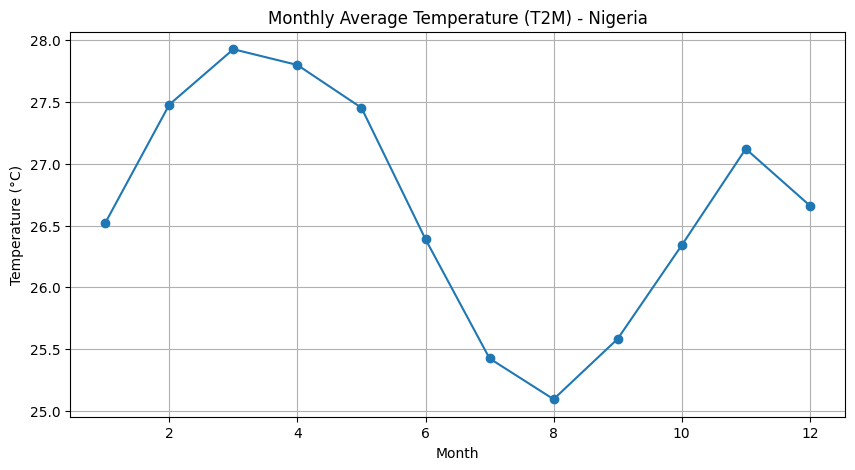

In [ ]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Nigeria")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [ ]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(3), np.int32(8))

##  Seasonal Temperature Extremes

Using monthly average temperature aggregation, the warmest and coolest months were identified based on the maximum and minimum mean temperatures respectively.

---

###  Warmest Month
- The **warmest month is Month 3 (March)**.
- This indicates that peak temperatures occur in the **early part of the year**, likely during the transition toward the hotter dry season.

---

###  Coolest Month
- The **coolest month is Month 8 (August)**.
- This suggests a mid-year temperature dip, which is often associated with **higher cloud cover and rainfall influence**, reducing surface heating.

---

##  Key Insight
The temperature cycle shows a clear **seasonal pattern**, where:
- Early-year months tend to be hotter due to lower rainfall and higher solar heating.
- Mid-year months are relatively cooler, likely due to increased precipitation and humidity effects.

This pattern reflects a **tropical seasonal climate influence**, where rainfall plays a major role in modulating temperature rather than extreme cold conditions.

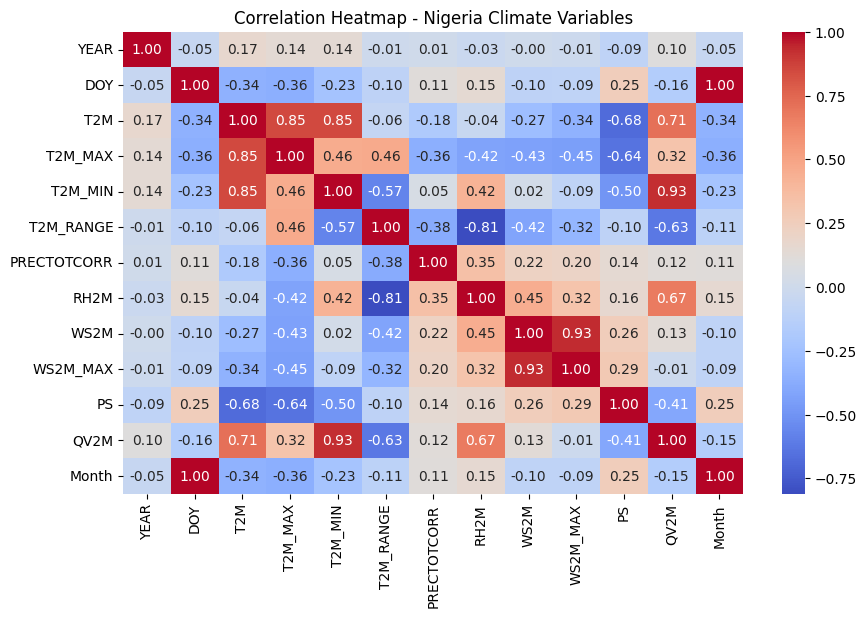

In [ ]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Nigeria Climate Variables")
plt.show()

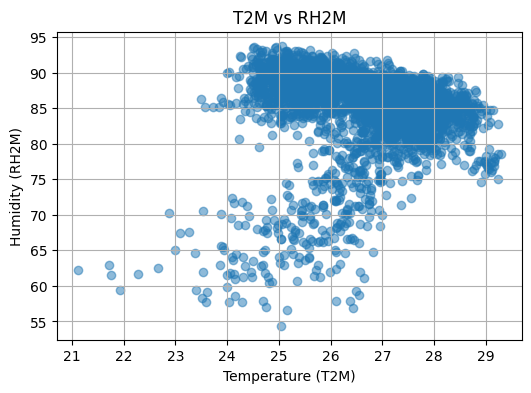

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

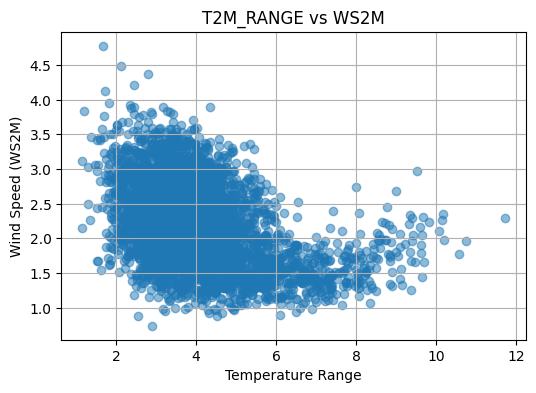

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [ ]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.930498
dtype: float64

##  Correlation Analysis – Strongest Relationships

The correlation matrix was unstacked and sorted to identify the strongest relationships between climate variables. Self-correlations (value = 1.0) were excluded to focus on meaningful variable interactions.

---

###  Top 3 Strongest Correlations

#### 1.  DOY and Month (r ≈ 0.997)
- There is an almost perfect positive correlation between **Day of Year (DOY)** and **Month**.
- This is expected because both variables represent time progression within a year.
- It confirms that the time features are **redundant in information content**, as one can be derived from the other.

---

#### 2.  WS2M_MAX and WS2M (r ≈ 0.930)
- A very strong positive correlation exists between **average wind speed (WS2M)** and **maximum wind speed (WS2M_MAX)**.
- This indicates that days with higher average wind speeds also tend to experience stronger peak gusts.
- It suggests a **consistent wind behavior pattern** rather than isolated gust events.

---

##  Key Insight
- The dataset contains a **highly redundant time feature pair (DOY–Month)**, which may not both be needed in predictive modeling.
- Wind speed variables are strongly linked, showing **stable atmospheric wind dynamics**.
- Other climate variables (temperature, humidity, precipitation) are not in the top correlations, indicating more **independent behavior across climate factors**.

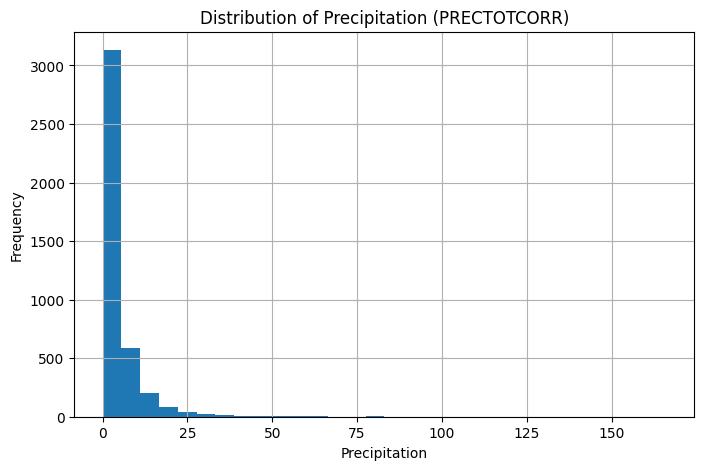

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

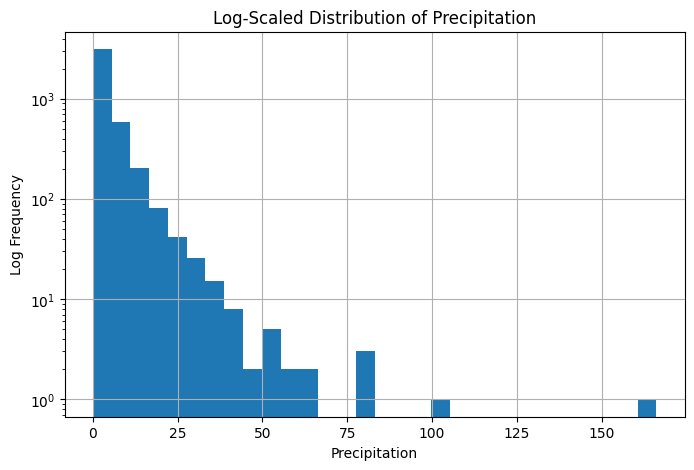

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

##  Distribution of Precipitation (Log-Scaled)

The histogram of **PRECTOTCORR (precipitation)** was plotted using a logarithmic scale on the frequency axis to better visualize the highly skewed distribution.

---

###  Observations

- The distribution is **strongly right-skewed**, meaning that most days experience **low or near-zero rainfall**.
- A large concentration of values is clustered close to **0–10 mm**, indicating that **light or no rain is the dominant daily condition**.
- There are a **small number of extreme rainfall events**, with values extending beyond **50 mm and reaching up to ~160 mm**.
- These extreme values appear as **isolated spikes**, confirming that heavy rainfall is **rare but significant**.

---

###  Effect of Log Scale
- The logarithmic scale reveals patterns that would otherwise be hidden by extreme values.
- It highlights the **long tail distribution**, where rare heavy rainfall events exist but occur infrequently.

---

##  Key Insight
The precipitation pattern reflects a **typical tropical seasonal rainfall regime**:
- Most days are dry or lightly wet  
- Rainfall is concentrated in specific periods (seasonal storms)  
- Extreme rainfall events are rare but impactful  

This type of distribution is important for:
- Flood risk analysis  
- Agricultural planning  
- Climate variability studies in the region  

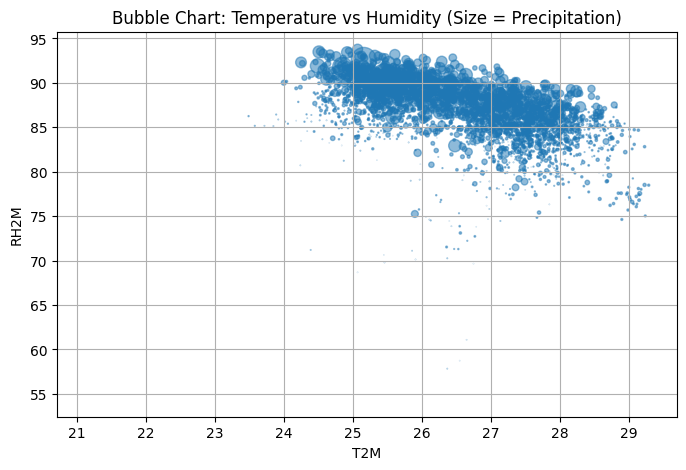

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()